# 03 Model Building and Evaluation
Here is the list of the main models that we will test in this notebook:
1. Decision Tree
2. Random Forest
3. K-Nearest Neighbors (KNN)
4. Support Vector Machine (SVM)
5. Stochastic Gradient Descent (SGD)
6. Logistic Regression

## 1. Import Libraries and Load Cleaned Data

In [59]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Statistical Methods
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)


# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier, LogisticRegression


In [5]:
# Load the cleaned dataset prepared in notebook 02
df = pd.read_csv("data/titanic_cleaned.csv")
print(df.shape)
df.head(10)

(891, 15)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Fam,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,0,22.0,1,0,7.2500,1,0,1,0,1,0,0
1,2,1,1,1,38.0,1,0,71.2833,1,0,0,0,1,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,0,1,0,1,0,0
3,4,1,1,1,35.0,1,0,53.1000,1,0,1,0,1,0,0
4,5,0,3,0,35.0,0,0,8.0500,0,0,1,0,1,0,0
5,6,0,3,0,28.0,0,0,8.4583,0,1,0,0,1,0,0
6,7,0,1,0,54.0,0,0,51.8625,0,0,1,0,0,1,0
7,8,0,3,0,2.0,3,1,21.0750,4,0,1,0,0,0,0
8,9,1,3,1,27.0,0,2,11.1333,2,0,1,0,1,0,0
9,10,1,2,1,14.0,1,0,30.0708,1,0,0,1,0,0,0


## 2. Prepare Features and Target

In [6]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print(X.shape)
print(len(y))

(891, 14)
891


We now split the data into training and testing splits for our initial model evaluation. Note that we will stratify on y to make sure that both training and testing datasets contain the same proportion of the Survived label.

In [7]:
# Train/test split by 80/20 rule
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100, stratify=y
)

A number of the learning methods used here do not work well without properly scaled data.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Fam,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
96,-1.369894,-1.578992,-0.719808,3.148589,-0.456784,-0.46164,0.053870,-0.535472,-0.311564,-1.657519,-0.289333,-1.443001,-0.418231,5.882176
220,-0.890761,0.823235,-0.719808,-1.032163,-0.456784,-0.46164,-0.471453,-0.535472,-0.311564,0.603311,3.456220,-1.443001,-0.418231,-0.170005
870,1.620824,0.823235,-0.719808,-0.272026,-0.456784,-0.46164,-0.474497,-0.535472,-0.311564,0.603311,-0.289333,0.693000,-0.418231,-0.170005
798,1.342618,0.823235,-0.719808,0.032028,-0.456784,-0.46164,-0.487660,-0.535472,-0.311564,-1.657519,-0.289333,0.693000,-0.418231,-0.170005
837,1.493313,0.823235,-0.719808,-0.119999,-0.456784,-0.46164,-0.471453,-0.535472,-0.311564,0.603311,-0.289333,0.693000,-0.418231,-0.170005


## 3. Train Models

In [97]:
# Define metrics used for model evaluation
scoring = ['accuracy', 'precision', 'recall', 'f1']

method = []
acc_scores =[]
pre_scores = []
rec_scores = []
f1_scores = []

### 3.1 Decision Tree

accuracy: 0.764 ± 0.032
precision: 0.700 ± 0.040
recall: 0.674 ± 0.057
f1: 0.686 ± 0.045
[[360  79]
 [ 89 184]]


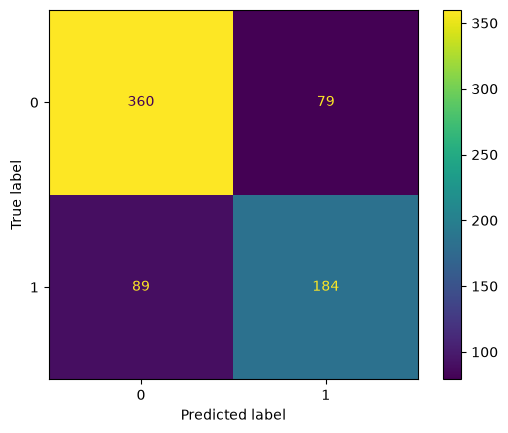

In [98]:
method.append("Decision Tree")
tree_clf = DecisionTreeClassifier(random_state=100)
tree_clf.fit(X_train, y_train)


cv_results = cross_validate(
    tree_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

acc_scores.append(cv_results['test_accuracy'].mean())
pre_scores.append(cv_results['test_precision'].mean())
rec_scores.append(cv_results['test_recall'].mean())
f1_scores.append(cv_results['test_f1'].mean())


from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_cv = cross_val_predict(
    tree_clf,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()
    

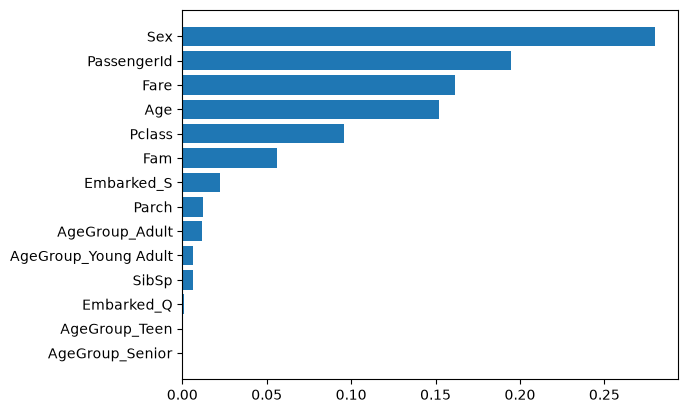

In [99]:
feature_importance = pd.Series(tree_clf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.barh(feature_importance.index, feature_importance.values)
plt.show()

### 3.2 Random Forest

accuracy: 0.802 ± 0.024
precision: 0.770 ± 0.058
recall: 0.700 ± 0.067
f1: 0.730 ± 0.033
[[380  59]
 [ 82 191]]


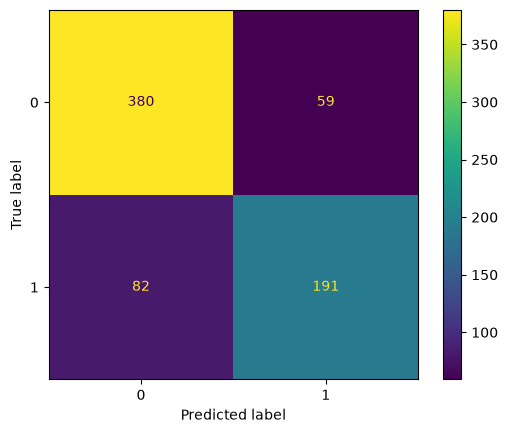

In [100]:
method.append("Random Forest")
forest_clf = RandomForestClassifier(random_state=100)
forest_clf.fit(X_train, y_train)


cv_results = cross_validate(
    forest_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

acc_scores.append(cv_results['test_accuracy'].mean())
pre_scores.append(cv_results['test_precision'].mean())
rec_scores.append(cv_results['test_recall'].mean())
f1_scores.append(cv_results['test_f1'].mean())

y_pred_cv = cross_val_predict(
    forest_clf,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()
    

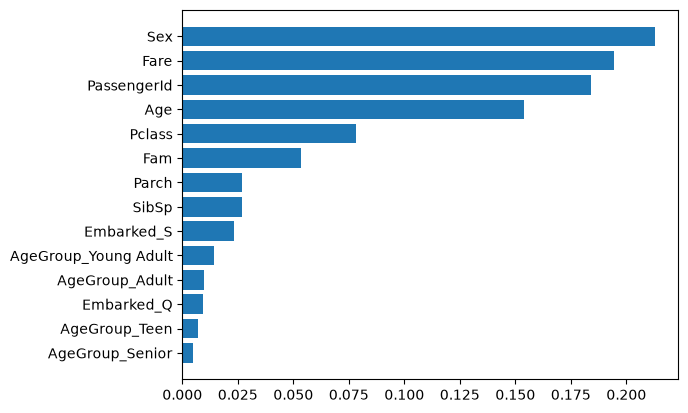

In [101]:
feature_importance = pd.Series(forest_clf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.barh(feature_importance.index, feature_importance.values)
plt.show()

### 3.3 K-Nearest Neighbors

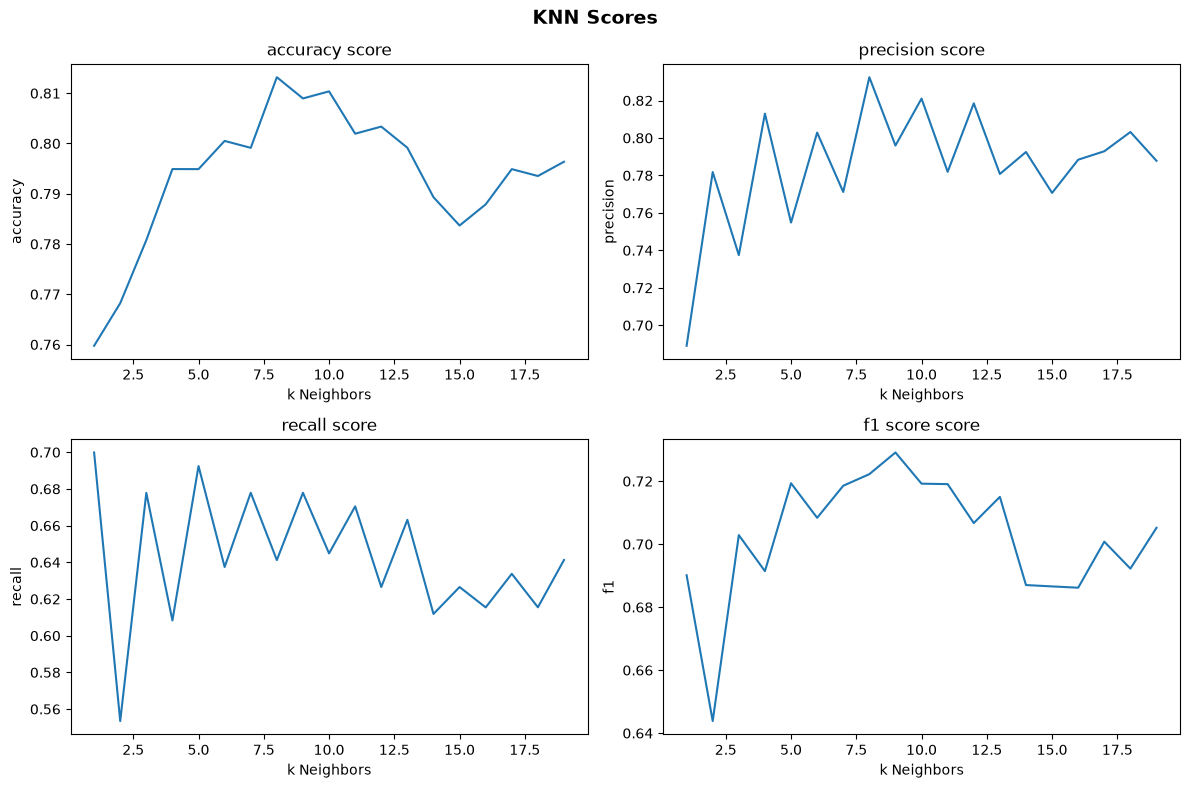

In [102]:
k_range = range(1,20)
k_acc = []
k_pre = []
k_rec = []
k_f1 = []

for k in k_range:
    KNN_clf = KNeighborsClassifier(n_neighbors=k)
    KNN_clf.fit(X_train, y_train)
    cv_results = cross_validate(
    KNN_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring)
    k_acc.append(cv_results['test_accuracy'].mean())
    k_pre.append(cv_results['test_precision'].mean())
    k_rec.append(cv_results['test_recall'].mean())
    k_f1.append(cv_results['test_f1'].mean())


# Plot results

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    squeeze=False
)
axes = axes.flatten()

axes[0].plot(k_range, k_acc)
axes[0].set_xlabel("k Neighbors")
axes[0].set_ylabel("accuracy")
axes[0].set_title("accuracy score")

axes[1].plot(k_range, k_pre)
axes[1].set_xlabel("k Neighbors")
axes[1].set_ylabel("precision")
axes[1].set_title("precision score")

axes[2].plot(k_range, k_rec)
axes[2].set_xlabel("k Neighbors")
axes[2].set_ylabel("recall")
axes[2].set_title("recall score")

axes[3].plot(k_range, k_f1)
axes[3].set_xlabel("k Neighbors")
axes[3].set_ylabel("f1")
axes[3].set_title("f1 score score")

plt.suptitle("KNN Scores", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


From the above, it seems that k=9 nearest neighbors is optimal, though very noisy, so shouldn't necessarily hold to this, especially with cross-evaluation which may smooth these scores.

accuracy: 0.809 ± 0.029
precision: 0.796 ± 0.044
recall: 0.678 ± 0.082
f1: 0.729 ± 0.050
[[391  48]
 [ 88 185]]


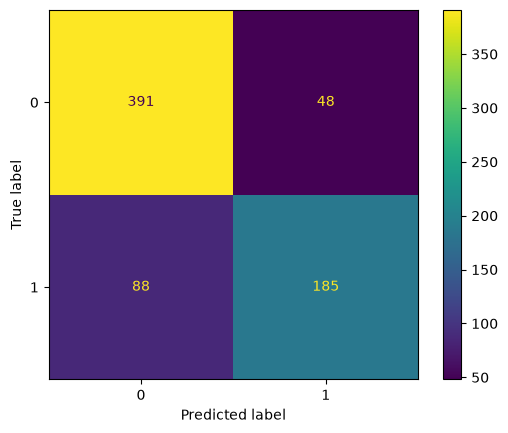

In [103]:
method.append("K-Nearest Neighbors")
KNN_clf = KNeighborsClassifier(n_neighbors=9)
KNN_clf.fit(X_train, y_train)


cv_results = cross_validate(
    KNN_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

acc_scores.append(cv_results['test_accuracy'].mean())
pre_scores.append(cv_results['test_precision'].mean())
rec_scores.append(cv_results['test_recall'].mean())
f1_scores.append(cv_results['test_f1'].mean())

y_pred_cv = cross_val_predict(
    KNN_clf,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()



### 3.4 Support Vector Machine

accuracy: 0.819 ± 0.034
precision: 0.815 ± 0.048
recall: 0.685 ± 0.069
f1: 0.742 ± 0.051
[[396  43]
 [ 86 187]]


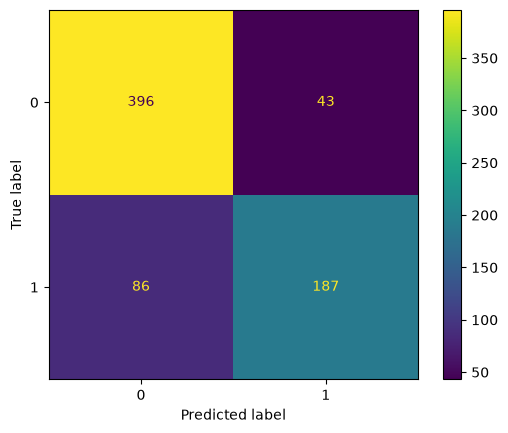

In [104]:
method.append("Support Vector Machine")
SVM_clf = SVC(random_state=100)
SVM_clf.fit(X_train, y_train)


cv_results = cross_validate(
    SVM_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

acc_scores.append(cv_results['test_accuracy'].mean())
pre_scores.append(cv_results['test_precision'].mean())
rec_scores.append(cv_results['test_recall'].mean())
f1_scores.append(cv_results['test_f1'].mean())

y_pred_cv = cross_val_predict(
    SVM_clf,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()



### 3.5 Stochastic Gradient Descent

accuracy: 0.774 ± 0.025
precision: 0.747 ± 0.050
recall: 0.626 ± 0.050
f1: 0.680 ± 0.035
[[380  59]
 [102 171]]


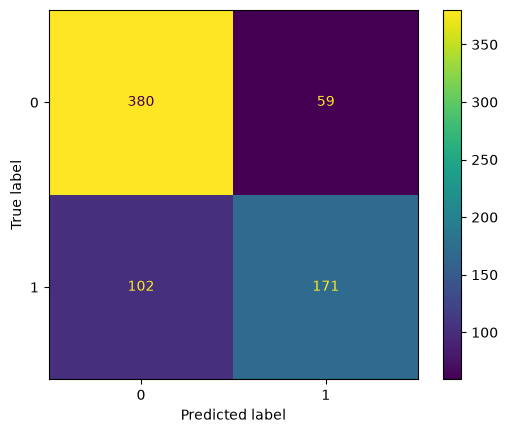

In [105]:
method.append("Stochastic Gradient Descent")
sgd_clf = SGDClassifier(random_state=100)
sgd_clf.fit(X_train, y_train)


cv_results = cross_validate(
    sgd_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

acc_scores.append(cv_results['test_accuracy'].mean())
pre_scores.append(cv_results['test_precision'].mean())
rec_scores.append(cv_results['test_recall'].mean())
f1_scores.append(cv_results['test_f1'].mean())

y_pred_cv = cross_val_predict(
    sgd_clf,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()




### 3.6 Logistic Regression

accuracy: 0.796 ± 0.018
precision: 0.760 ± 0.021
recall: 0.689 ± 0.076
f1: 0.720 ± 0.039
[[379  60]
 [ 85 188]]


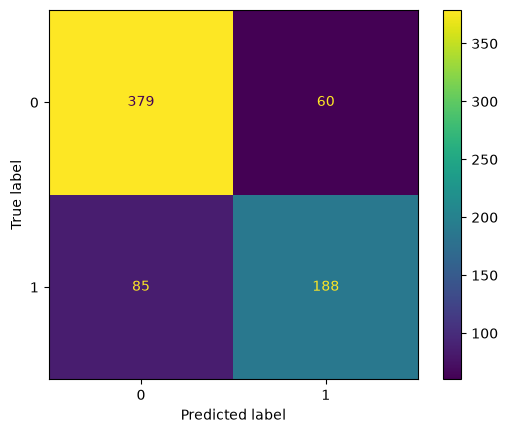

In [106]:
method.append("Logistic Regression")
log_clf = LogisticRegression(random_state=100, max_iter=2000)
log_clf.fit(X_train, y_train)


cv_results = cross_validate(
    log_clf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")

acc_scores.append(cv_results['test_accuracy'].mean())
pre_scores.append(cv_results['test_precision'].mean())
rec_scores.append(cv_results['test_recall'].mean())
f1_scores.append(cv_results['test_f1'].mean())

y_pred_cv = cross_val_predict(
    log_clf,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()




## 4. Model Evaluation

### 4.1 Metric Comparison

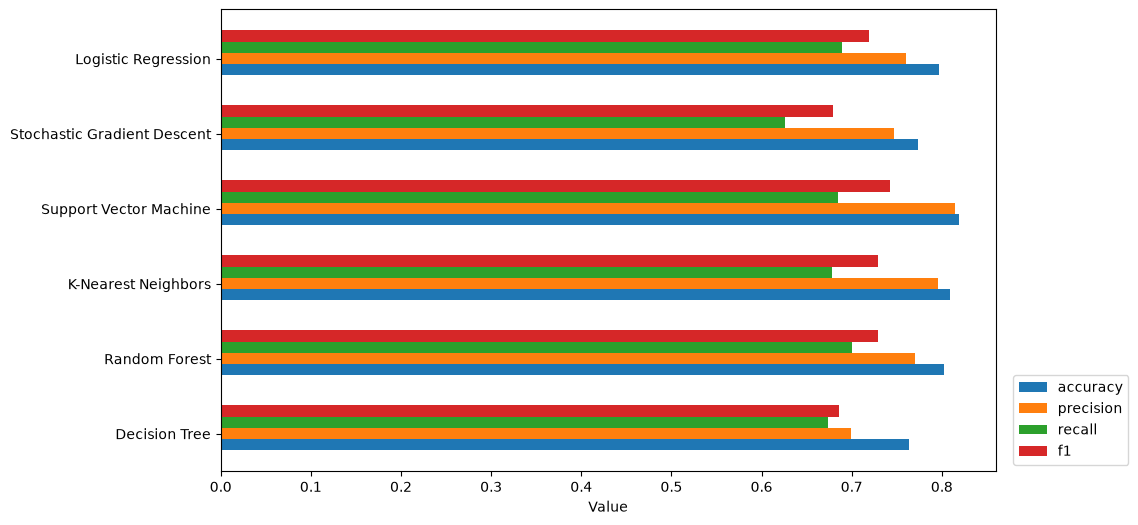

In [107]:
x = np.arange(len(method))

width = 0.15

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(x - width, acc_scores, width, label="accuracy")
ax.barh(x,         pre_scores, width, label="precision")
ax.barh(x + width, rec_scores, width, label="recall")
ax.barh(x + 2*width, f1_scores, width, label="f1")

ax.set_yticks(x)
ax.set_yticklabels(method)

ax.set_xlabel("Value")
ax.legend(loc="lower right", bbox_to_anchor=(1.18,0))

plt.show()

### 4.2 ROC Curve Comparison

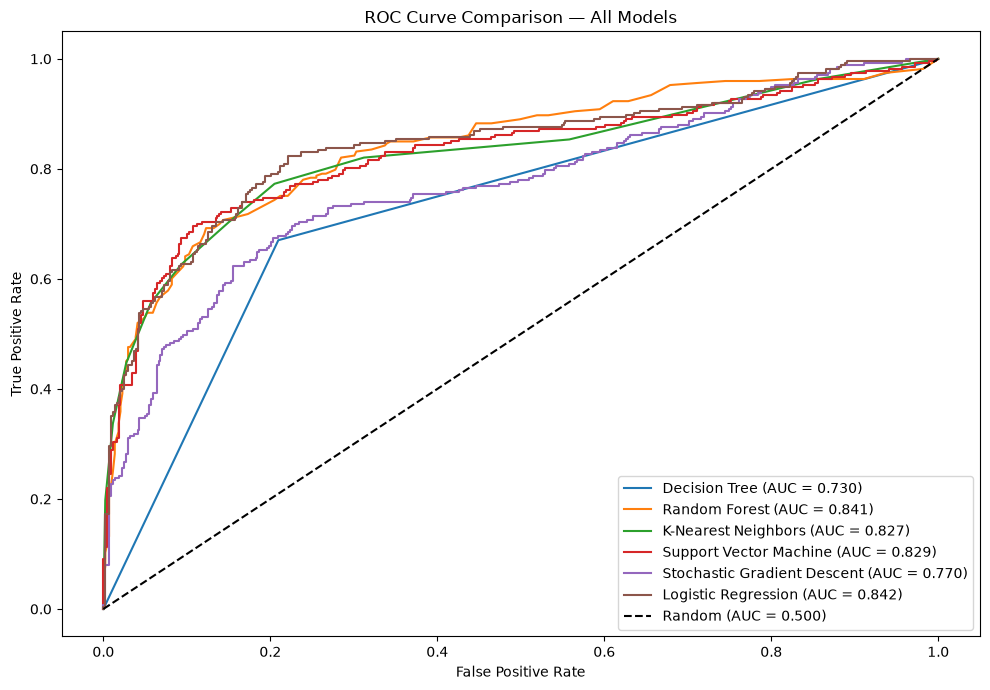

In [108]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=100
)

ROC_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=100),
    "Random Forest": RandomForestClassifier(random_state=100),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=10),
    "Support Vector Machine": SVC(random_state=100),
    "Stochastic Gradient Descent": SGDClassifier(random_state=100),
    "Logistic Regression": LogisticRegression(random_state=100, max_iter=10000)
}

plt.figure(figsize=(10, 7))

for name, model in ROC_models.items():
    if hasattr(model, "predict_proba"):
        y_scores = cross_val_predict(
            model,
            X_train,
            y_train,
            cv=cv,
            method="predict_proba"
        )[:, 1]
    else:
        y_scores = cross_val_predict(
            model,
            X_train,
            y_train,
            cv=cv,
            method="decision_function"
        )
    
    fpr, tpr, thresholds = roc_curve(y_train, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



### 4.4 Summary of Findings
From the metric comparison, the top 4 models are:
1. Support Vector Machine
2. K-Nearest Neighbors
3. Logistic Regression
4. Random Forest

From the ROC curve, we find the ranking to be:
1. Logistic Regression
2. Random Forest
3. Support Vector Machine
4. K-Nearest Neighbors

We choose to focus on **Random Forest** and **Logistic Regression** in the following.

## 5. Fine-Tuning Parameters

### 5.1 Random Forest

#### 5.1.a Fine-Tuning (GridSearchCV)

In [109]:
param_grid = {
    "n_estimators": [35, 40, 45, 50],
    "max_depth": [10, 12, 14],
    "min_samples_split": [4, 5, 6, 7, 8],
    "min_samples_leaf": [1, 2, 3]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=100),
    param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_}")

Best parameters: {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 45}
Best F1 Score: 0.7648330976171087


#### 5.1.b Fine-Tuned Model Scores

accuracy: 0.829 ± 0.027
precision: 0.817 ± 0.076
recall: 0.726 ± 0.051
f1: 0.765 ± 0.030
[[392  47]
 [ 75 198]]


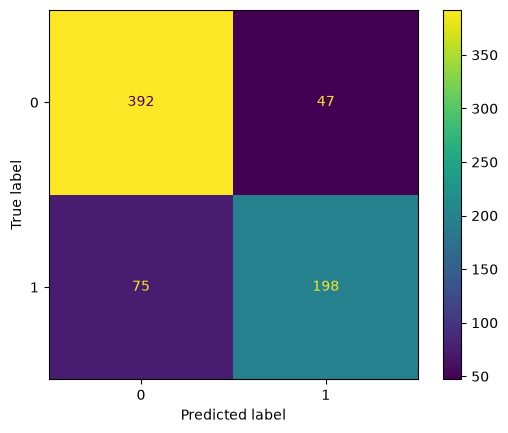

In [110]:
best_rf = grid_search.best_estimator_


cv_results = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")


y_pred_cv = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()



In [111]:
best_rf = grid_search.best_estimator_
best_rf_acc = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="accuracy")
best_rf_pre = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="precision")
best_rf_rec = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="recall")
best_rf_f1 = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="f1")

print(f"Accuracy: {best_rf_acc.mean()} \u00B1 {best_rf_acc.std()}")
print(f"Precision: {best_rf_pre.mean()} \u00B1 {best_rf_pre.std()}")
print(f"Recall: {best_rf_rec.mean()} \u00B1 {best_rf_rec.std()}")
print(f"F1: {best_rf_f1.mean()} \u00B1 {best_rf_f1.std()}")

Accuracy: 0.828582684920713 ± 0.026573700366649824
Precision: 0.8166706402635551 ± 0.07570269806064021
Recall: 0.7255218855218856 ± 0.05065942736074889
F1: 0.7648330976171087 ± 0.030413305306795594


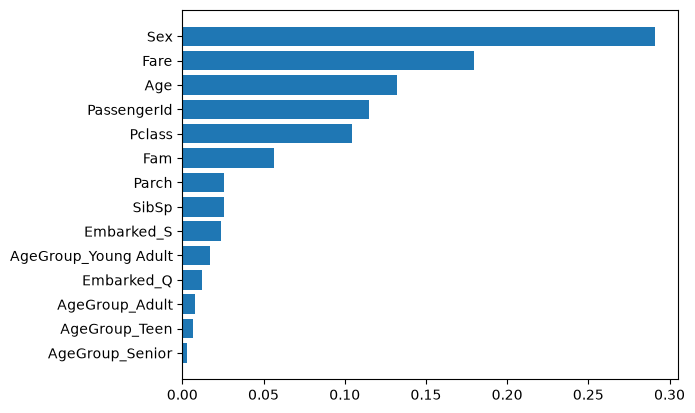

In [112]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.barh(feature_importance.index, feature_importance.values)
plt.show()

### 5.2 Fine-Tuning Parameters - Logistic Regression

#### 5.2.a Fine-Tuning (GridSearchCV)
Note, we have to be careful about compatabilities, i.e.
- lbfgs, newton-cg, sag only work with L2 ratio (i.e. l1_ratio = 0)
- liblinear and saga work with l1_ratio *either* 0 or 1

In [113]:
param_grid = [
    {
        "C": [0.01, 0.1, 1, 10, 100, 200, 500, 1000],
        "l1_ratio": [0],
        "solver": ["lbfgs", "newton-cg", "sag"],
        "max_iter": [2500, 5000, 7500, 10000]
    },
    {
        "C": [0.01, 0.1, 1, 10, 100, 200, 500, 1000],
        "l1_ratio": [0, 1],
        "solver": ["liblinear", "saga"],
        "max_iter": [2500, 5000, 7500, 10000]
    }
]


grid_search = GridSearchCV(
    LogisticRegression(random_state=100),
    param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_}")



Best parameters: {'C': 100, 'l1_ratio': 0, 'max_iter': 2500, 'solver': 'lbfgs'}
Best F1 Score: 0.7300977075784227


#### 5.2.b Fine-Tuned Model Scores

accuracy: 0.801 ± 0.017
precision: 0.759 ± 0.031
recall: 0.707 ± 0.060
f1: 0.730 ± 0.029
[[377  62]
 [ 80 193]]


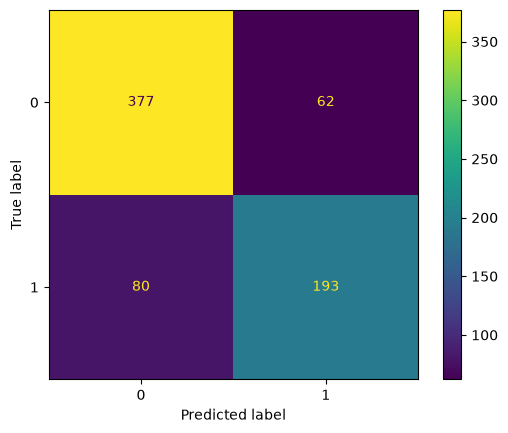

In [114]:
best_lg = grid_search.best_estimator_


cv_results = cross_validate(
    best_lg,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")


y_pred_cv = cross_val_predict(
    best_lg,
    X_train,
    y_train,
    cv=5
)

cm = confusion_matrix(y_train, y_pred_cv)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()



In [115]:
best_lg = grid_search.best_estimator_
best_lg_acc = cross_val_score(best_lg, X_train, y_train, cv=5, scoring="accuracy")
best_lg_pre = cross_val_score(best_lg, X_train, y_train, cv=5, scoring="precision")
best_lg_rec = cross_val_score(best_lg, X_train, y_train, cv=5, scoring="recall")
best_lg_f1 = cross_val_score(best_lg, X_train, y_train, cv=5, scoring="f1")

print(f"Accuracy: {best_lg_acc.mean()} \u00B1 {best_lg_acc.std()}")
print(f"Precision: {best_lg_pre.mean()} \u00B1 {best_lg_pre.std()}")
print(f"Recall: {best_lg_rec.mean()} \u00B1 {best_lg_rec.std()}")
print(f"F1: {best_lg_f1.mean()} \u00B1 {best_lg_f1.std()}")

Accuracy: 0.8005417118093174 ± 0.017181503185154465
Precision: 0.7591574475221964 ± 0.03062494115487717
Recall: 0.7072053872053872 ± 0.06012627146446905
F1: 0.7300977075784227 ± 0.029336522902811992


### 5.3 Final Comparison

**Random Forest**
- Accuracy: 0.828582684920713 ± 0.026573700366649824
- Precision: 0.8166706402635551 ± 0.07570269806064021
- Recall: 0.7255218855218856 ± 0.05065942736074889
- F1: 0.7648330976171087 ± 0.030413305306795594

**Logistic Regression**
- Accuracy: 0.8005417118093174 ± 0.017181503185154465
- Precision: 0.7591574475221964 ± 0.03062494115487717
- Recall: 0.7072053872053872 ± 0.06012627146446905
- F1: 0.7300977075784227 ± 0.029336522902811992

**Random Forest** performed the best after hyperparameter tuning!

## 6. Test Data Performance

Accuracy: 0.8603351955307262
Precision: 0.8055555555555556
Recall: 0.8405797101449275
F1: 0.8226950354609929
[[96 14]
 [11 58]]


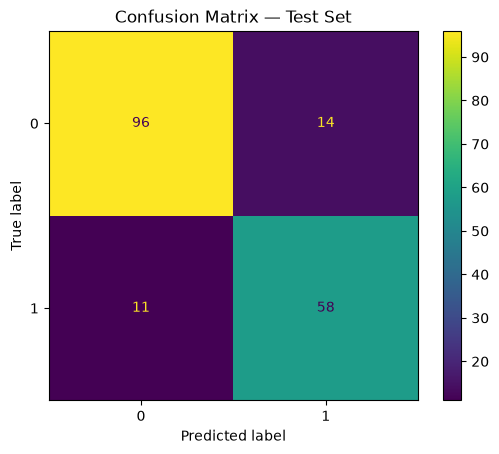

In [136]:
best_model = best_rf
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix — Test Set")
plt.show()


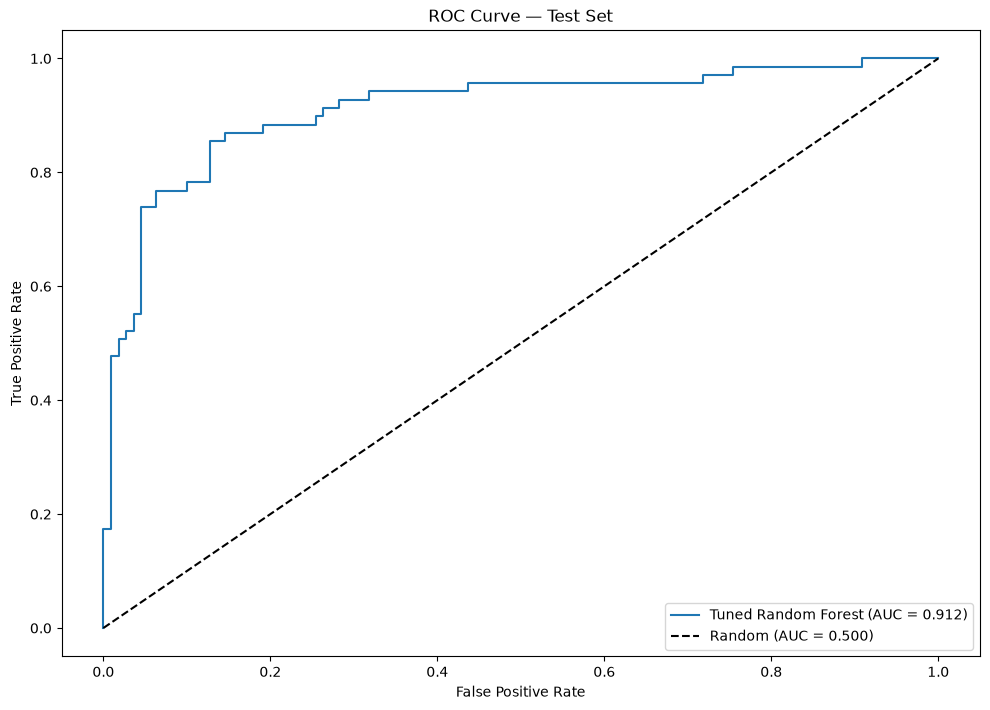

In [134]:

plt.figure(figsize=(10, 7))

y_score = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"Tuned Random Forest (AUC = {roc_auc:.3f})")


plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.title("ROC Curve — Test Set")
plt.show()


## 7. Final Summary
**Random Forest** was the best predictor on the test set, having scores:
- Accuracy: 0.860
- Precision: 0.806
- Recall: 0.841
- F1: 0.823
- AUC 0.912

#### Key Takeaways

1. **Sex** was by far the most important feature for predicting survival
2. **Feature engineering** (e.g. Fam, AgeGroup) did not have a significant impact on model performance
3. **Model tuning** with GridSearchCV meaningfully improved the Random Forest model
4. There was no strictly obvious outlier in models
5. Data standardization was utilized to improve model accuracy